In [1]:
import pandas as pd
import os
import numpy as np

In [2]:
pd.set_option('display.max_columns', None)

Step 1: Load Kunkle GWAS Data + Data Cleaning/Standardization

In [3]:
Temp = pd.read_csv("GWASdata.txt", sep = r"\s+")

gwas = pd.read_csv("Kunkle_etal_Stage1_results 1 (1).txt", skiprows = 1,sep = r"\s+")
gwas.columns = Temp.columns
print(gwas.head())


   Chromosome   Position        MarkerName Effect_allele Non_Effect_allele  \
0           3  110886586         rs7610760             A                 G   
1           3  110887310  chr3:110887310:D           CAT                 C   
2           3  110887920       rs143050383             T                 G   
3           3  110888751        rs17281053             T                 C   
4           3  110888869       rs150449154             C                 G   

     Beta      SE  Pvalue  
0 -0.0058  0.0279  0.8351  
1 -0.0090  0.0276  0.7451  
2  0.0490  0.1155  0.6718  
3  0.0213  0.0433  0.6229  
4  0.1719  0.1614  0.2869  


In [4]:
gwas["MarkerName"].isin(["rs429358"]).any()
#Check if APOE is here

np.True_

Step 2: Slight Adjustments Because of Weird Data Stuff and then Filtering based on P Value of 5E-8. Some column renaming and identifying the major chromosomes involved in these significant interactions

In [5]:
gwas.columns = Temp.columns
gwas = pd.concat([gwas, Temp])
print(gwas["Chromosome"].value_counts())

Chromosome
1     883510
4     841113
6     791364
3     776137
5     750123
2     741140
7     667314
8     640583
10    592369
11    567610
12    548865
9     496550
13    428339
14    376881
16    342600
18    327651
15    324332
17    296957
20    249652
19    249037
21    154628
22    153541
Name: count, dtype: int64


In [6]:
gwas = gwas[gwas["Pvalue"] < 5E-8]
gwas_sig = gwas[["MarkerName", "Chromosome", "Position"]]
gwas_sig.columns = ["SNP", "CHR", "BP"]
gwas_sig["chr"] = "chr" + gwas_sig["CHR"].astype(str)
print(len(gwas_sig))
print(gwas_sig["CHR"].value_counts())
print("Chromosomes that have statistically significant SNPS", gwas_sig["CHR"].unique())
print(gwas_sig["SNP"].isin(["rs429358"]).any())

1514
CHR
19    790
11    526
6      79
2      65
1      23
8      21
7       6
10      3
14      1
Name: count, dtype: int64
Chromosomes that have statistically significant SNPS [ 6  7  8 10 11 14 19  1  2]
True


/tmp/ipykernel_3867929/555377219.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gwas_sig["chr"] = "chr" + gwas_sig["CHR"].astype(str)


Step 3: Convert SNPS to Genomic Intervals (BED Format)

In [7]:
gwas_sig["start"] = gwas_sig["BP"]
gwas_sig["end"] = gwas_sig["BP"] + 1
snps = gwas_sig[["chr", "start", "end", "SNP"]]

snps.head()

/tmp/ipykernel_3867929/1336155299.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gwas_sig["start"] = gwas_sig["BP"]
/tmp/ipykernel_3867929/1336155299.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gwas_sig["end"] = gwas_sig["BP"] + 1


,chr,start,end,SNP
2813223,chr6,32386619,32386620,rs4335021
2813362,chr6,32394098,32394099,rs3135348
2816863,chr6,32488381,32488382,rs112077796
2818991,chr6,32521901,32521902,chr6:32521901:I
2819382,chr6,32526951,32526952,chr6:32526951:I


In [8]:
BIN_SIZE = 5000
snps["bin_start"] = (snps["start"] // BIN_SIZE) * BIN_SIZE
snps["bin_end"] = snps["bin_start"] + BIN_SIZE

/tmp/ipykernel_3867929/3172042562.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  snps["bin_start"] = (snps["start"] // BIN_SIZE) * BIN_SIZE


In [9]:
data_path = "GM12878"
files = os.listdir(data_path)
print(files[:10])

['chr1_5kb.txt', 'chr2_5kb.txt', 'chr3_5kb.txt', 'chr4_5kb.txt', 'chr6_5kb.txt', 'chr7_5kb.txt', 'chr5_5kb.txt', 'chr14_5kb.txt', 'chr8_5kb.txt', 'chr9_5kb.txt']


Step 4: Loading in Chromosomal Positional Data. For Loop since they are separated by chromosome

In [10]:
file_path = os.path.join(data_path, "chr1_5kb.txt")
hic3d = pd.read_csv(file_path, sep = "\t")

for i in range(2,23):
    file_path = os.path.join(data_path, f"chr{i}_5kb.txt")
    temp_df = pd.read_csv(file_path, sep = "\t")
    if i == 21:
        temp_df.columns = hic3d.columns
    hic3d = pd.concat([hic3d, temp_df])
hic3d.tail()
hic3d[["x", "y", "z"]].describe()

,x,y,z
count,493083.000000,493083.000000,493083.000000
mean,0.000035,-0.005211,0.011484
std,0.279353,0.464171,0.352408
min,-1.939265,-2.843725,-2.378973
25%,-0.069613,-0.049729,-0.040491
50%,0.009715,0.001845,0.001318
75%,0.073191,0.053759,0.041507
max,3.243274,2.331901,1.956525


Step 4: Loading in Chromosomal Positional Data. For Loop since they are separated by chromosome

In [11]:
merged = snps.merge(hic3d, left_on = ["chr", "bin_start"], right_on = ["chr", "start"])
print("SNPs before merge:", len(snps))
print("SNPs after merge:", len(merged))
print(merged.head())
print(merged["SNP"].isin(["rs429358"]).any())

SNPs before merge: 1514
SNPs after merge: 1511
    chr   start_x     end_x              SNP  bin_start   bin_end     start_y  \
0  chr6  32386619  32386620        rs4335021   32385000  32390000  32385000.0   
1  chr6  32394098  32394099        rs3135348   32390000  32395000  32390000.0   
2  chr6  32488381  32488382      rs112077796   32485000  32490000  32485000.0   
3  chr6  32521901  32521902  chr6:32521901:I   32520000  32525000  32520000.0   
4  chr6  32526951  32526952  chr6:32526951:I   32525000  32530000  32525000.0   

        end_y         x         y         z  
0  32390000.0 -0.132567 -0.058339  0.055222  
1  32395000.0 -0.134307 -0.059308  0.054915  
2  32490000.0 -0.140592 -0.054118  0.044624  
3  32525000.0 -0.139481 -0.064568  0.050685  
4  32530000.0 -0.140566 -0.064681  0.050530  
True


Step 5: Threshold Positional Investigation

In [12]:
# Check what a reasonable threshold looks like
sample_snp = merged.iloc[0]
dists = np.sqrt((hic3d["x"] - sample_snp["x"])**2 + 
                (hic3d["y"] - sample_snp["y"])**2 + 
                (hic3d["z"] - sample_snp["z"])**2)
print(dists.describe())
print("5%:", np.percentile(dists, 5))
print("1%:", np.percentile(dists, 1))
print("0.1%:", np.percentile(dists, 0.1))
print("0.01%:", np.percentile(dists, 0.01))


count    493083.000000
mean          0.373099
std           0.548452
min           0.000000
25%           0.137748
50%           0.199364
75%           0.255622
max           3.928255
dtype: float64
5%: 0.07630718202902834
1%: 0.04600951223470159
0.1%: 0.020592679227138064
0.01%: 0.007098108735989541


Step 6: KD-Tree for Fast Nearest Neighbor Assignment

In [13]:
from scipy.spatial import cKDTree

# Build KD-tree for fast spatial lookup
coords = hic3d[["x","y","z"]].values
tree = cKDTree(coords)

# Query neighbors
DIST_THRESHOLD = 0.02Í  # adjust after checking distribution
interactions = []

GENOMIC_THRESHOLD = 50000  # 50 kb

for _, snp in merged.iterrows():
    snp_coord = [snp["x"], snp["y"], snp["z"]]
    
    idx = tree.query_ball_point(snp_coord, DIST_THRESHOLD)
    close_bins = hic3d.iloc[idx]
    # Apply genomic distance filter
    filtered_bins = close_bins[
        (close_bins["chr"] == snp["chr"]) &
        (abs(close_bins["start"] - snp["bin_start"]) > GENOMIC_THRESHOLD)
    ]
    
    interactions.append(filtered_bins)
print("After spatial filter:", len(close_bins))
print("After genomic filter:", len(filtered_bins))

After spatial filter: 52
After genomic filter: 30


In [14]:
print(interactions[0])
results = []

for i, df in enumerate(interactions):
    if len(df) == 0:
        continue
    
    temp = df.copy()
    temp["SNP"] = merged.iloc[i]["SNP"]
    temp["snp_bin_start"] = merged.iloc[i]["bin_start"]  # ← add this line
    results.append(temp)

results_df = pd.concat(results, ignore_index=True)
print(results_df.columns)

       chr       start         end         x         y         z
6057  chr6  31530000.0  31535000.0 -0.130554 -0.062598  0.050824
6054  chr6  31515000.0  31520000.0 -0.131322 -0.062051  0.050800
6062  chr6  31555000.0  31560000.0 -0.130667 -0.062623  0.050850
6055  chr6  31520000.0  31525000.0 -0.131184 -0.062532  0.050978
6056  chr6  31525000.0  31530000.0 -0.131722 -0.062723  0.051672
6275  chr6  32665000.0  32670000.0 -0.135643 -0.060541  0.054470
6274  chr6  32660000.0  32665000.0 -0.137441 -0.061680  0.053312
6071  chr6  31600000.0  31605000.0 -0.132637 -0.058513  0.054686
6052  chr6  31505000.0  31510000.0 -0.131644 -0.060953  0.049021
6070  chr6  31595000.0  31600000.0 -0.131470 -0.059324  0.053642
6053  chr6  31510000.0  31515000.0 -0.130842 -0.061435  0.049783
6074  chr6  31615000.0  31620000.0 -0.130708 -0.057702  0.054775
6069  chr6  31590000.0  31595000.0 -0.129901 -0.059791  0.052482
6068  chr6  31585000.0  31590000.0 -0.128991 -0.060304  0.051239
6067  chr6  31580000.0  3

Step 7: Gene Annotation of Notable Interactions

In [15]:
import pandas as pd

gtf = pd.read_csv(
    "gencode.v49.basic.annotation.gtf.gz",
    sep="\t",
    comment="#",
    header=None
)

In [16]:
gtf.columns = [
    "chr", "source", "feature", "start", "end",
    "score", "strand", "frame", "attribute"
]

In [17]:
genes = gtf[gtf["feature"] == "gene"].copy()
print(genes.head())

      chr   source feature  start    end score strand frame  \
0    chr1   HAVANA    gene  11121  24894     .      +     .   
6    chr1   HAVANA    gene  12010  13670     .      +     .   
14   chr1   HAVANA    gene  14356  30744     .      -     .   
108  chr1   HAVANA    gene  14696  24886     .      -     .   
120  chr1  ENSEMBL    gene  17369  17436     .      -     .   

                                             attribute  
0    gene_id "ENSG00000290825.2"; gene_type "lncRNA...  
6    gene_id "ENSG00000223972.6"; gene_type "transc...  
14   gene_id "ENSG00000310526.1"; gene_type "lncRNA...  
108  gene_id "ENSG00000227232.6"; gene_type "transc...  
120  gene_id "ENSG00000278267.1"; gene_type "miRNA"...  


In [18]:
import re

def extract_gene_name(attr):
    match = re.search('gene_name "([^"]+)"', attr)
    return match.group(1) if match else None

genes["gene_name"] = genes["attribute"].apply(extract_gene_name)

In [19]:
genes["chr"].unique()[:21]
genes.columns

Index(['chr', 'source', 'feature', 'start', 'end', 'score', 'strand', 'frame',
       'attribute', 'gene_name'],
      dtype='object')

In [20]:
results_df.head()

,chr,start,end,x,y,z,SNP,snp_bin_start
0,chr6,31530000.0,31535000.0,-0.130554,-0.062598,0.050824,rs4335021,32385000
1,chr6,31515000.0,31520000.0,-0.131322,-0.062051,0.050800,rs4335021,32385000
2,chr6,31555000.0,31560000.0,-0.130667,-0.062623,0.050850,rs4335021,32385000
3,chr6,31520000.0,31525000.0,-0.131184,-0.062532,0.050978,rs4335021,32385000
4,chr6,31525000.0,31530000.0,-0.131722,-0.062723,0.051672,rs4335021,32385000


In [21]:
%pip install pyranges

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


Step 8: Pathway Enrichment Analysis Using PyRanges

In [22]:
import pyranges as pr
#Identify Promoter Overlap
bins_pr = pr.PyRanges(results_df.rename(columns={
    "chr": "Chromosome",
    "start": "Start",
    "end": "End"
}))

genes_pr = pr.PyRanges(genes.rename(columns={
    "chr": "Chromosome",
    "start": "Start",
    "end": "End"
}))

gene_hits = bins_pr.join(genes_pr)
gene_list = gene_hits.df["gene_name"].dropna().unique()
print(gene_list)

['CR1' 'CR1-AS1' 'CACNA1S' 'KIF21B' 'ENSG00000234132' 'LINC01740' 'ASCL5'
 'TMEM9' 'ENSG00000308069' 'CD46' 'MIR29B2CHG' 'CD34' 'LINC02767' 'MIR29C'
 'MIR29B2' 'ENSG00000289071' 'ENSG00000308170' 'ENSG00000308151'
 'ENSG00000308093' 'ENSG00000308132' 'CR1L' 'CDCA4P4' 'AMER3'
 'ENSG00000308399' 'GPR39' 'ENSG00000229797' 'TMEM163' 'SAP130'
 'ENSG00000204399' 'MGAT5' 'ENSG00000297469' 'MCCD1' 'DDX39B'
 'ATP6V1G2-DDX39B' 'ENSG00000256851' 'PPIAP9' 'NFKBIL1' 'ENSG00000289406'
 'RPL15P4' 'HLA-DQB1' 'ENSG00000303029' 'HLA-DQB1-AS1' 'MICB'
 'ENSG00000289375' 'AIF1' 'NCR3' 'LST1' 'LTB' 'ENSG00000301898' 'PRRC2A'
 'ENSG00000291302' 'SNORA38' 'ENSG00000289282' 'LTA' 'TNF'
 'ENSG00000302994' 'UQCRHP1' 'HLA-DQA2' 'MIR3135B' 'HLA-DQB3'
 'ENSG00000232080' 'MTCO3P1' 'ENSG00000309733' 'HLA-DQA1'
 'ENSG00000299769' 'ENSG00000299747' 'HLA-DRA' 'TSBP1-AS1' 'BTNL2'
 'ENSG00000307907' 'HLA-DRB1' 'ENSG00000307923' 'ENSG00000298454' 'KIF6'
 'ENSG00000309400' 'ENSG00000237530' 'ENSG00000301967' 'ENSG0000027907

In [23]:
set(gene_list) & {"APOE", "TREM2", "APP"}

{'TREM2'}

In [24]:
#%pip install gprofiler-official

In [25]:
gene_list = (
    gene_hits.df["gene_name"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)
from gprofiler import GProfiler

gp = GProfiler(return_dataframe=True)

enrich_results = gp.profile(
    organism='hsapiens',
    query=gene_list
)
print("Done")

Done


In [26]:
print(enrich_results.shape[0])

print(enrich_results.head(100))
sig = enrich_results[enrich_results["significant"] == True]
sig = sig.sort_values("p_value")


87
   source      native                                               name  \
0   GO:BP  GO:0002923  regulation of humoral immune response mediated...   
1    KEGG  KEGG:05310                                             Asthma   
2    KEGG  KEGG:04640                         Hematopoietic cell lineage   
3   GO:BP  GO:0050778             positive regulation of immune response   
4    KEGG  KEGG:04940                           Type I diabetes mellitus   
..    ...         ...                                                ...   
82  GO:BP  GO:0002876  positive regulation of chronic inflammatory re...   
83  GO:BP  GO:0002491  antigen processing and presentation of endogen...   
84  GO:BP  GO:0002469  myeloid dendritic cell antigen processing and ...   
85  CORUM   CORUM:120                  Lymphotoxin beta receptor complex   
86  GO:MF  GO:0140355                     cargo receptor ligand activity   

         p_value  significant  \
0   6.398725e-07         True   
1   7.507550e-07  

Step 9: Plotting Data

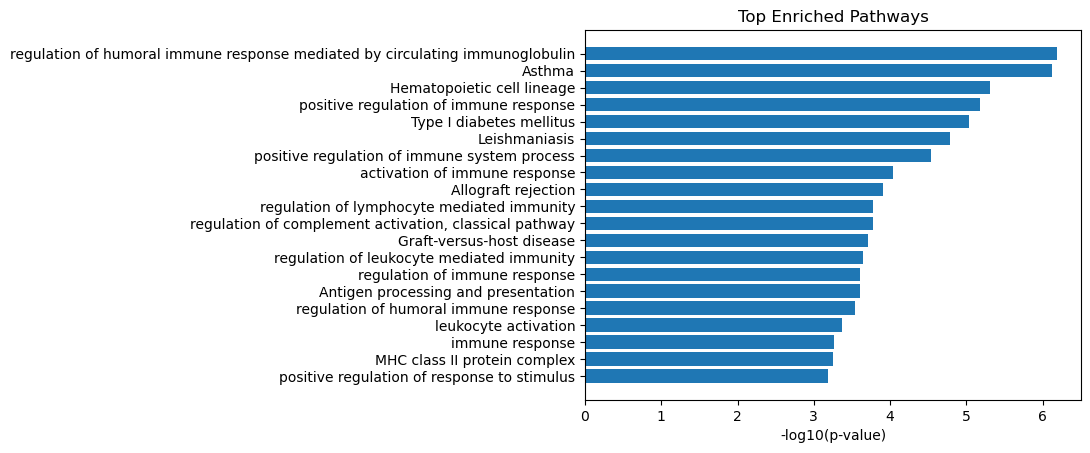

In [27]:
import matplotlib.pyplot as plt

top = sig.head(20)

plt.barh(top["name"], -np.log10(top["p_value"]))
plt.xlabel("-log10(p-value)")
plt.title("Top Enriched Pathways")
plt.gca().invert_yaxis()
plt.show()

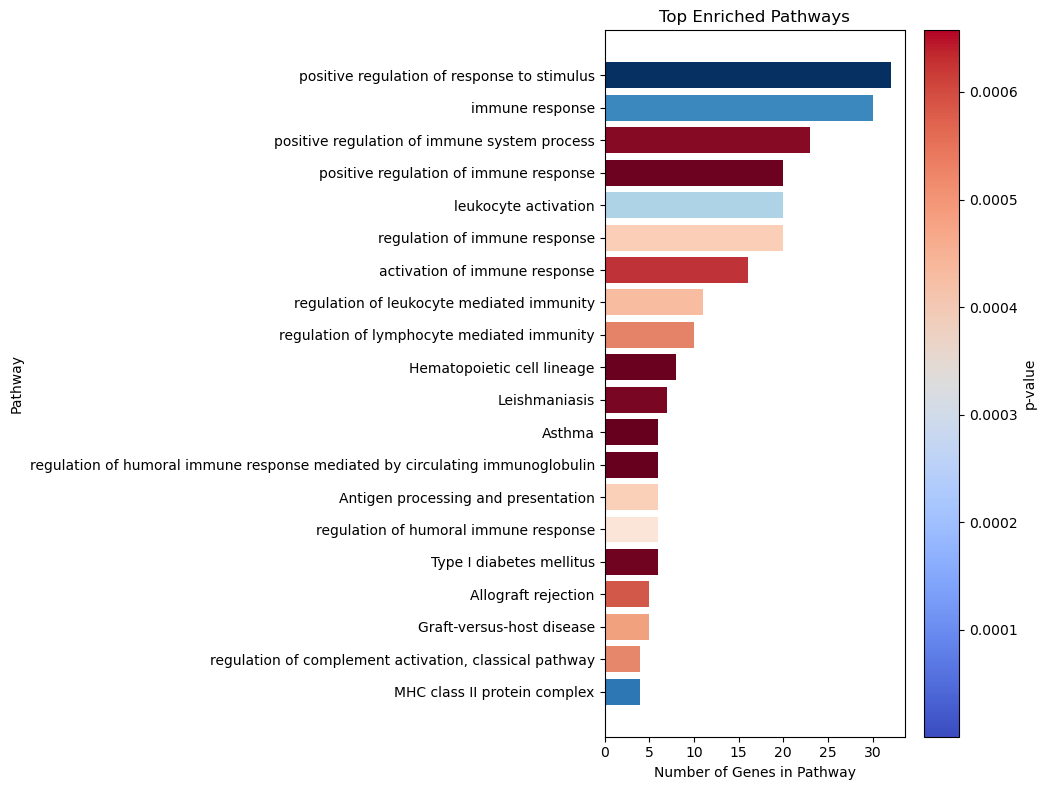

In [28]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
top = sig.head(20).copy()
top = top[top["name"] != "response to stimulus"]
top = top.sort_values("intersection_size", ascending=False)
# Map p-values to colors (red = most significant, blue = least)
norm = mcolors.Normalize(vmin=top["p_value"].min(), vmax=top["p_value"].max())
colors = cm.RdBu(norm(top["p_value"]))

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(top["name"], top["intersection_size"], color=colors)

ax.set_xlabel("Number of Genes in Pathway")
ax.set_ylabel("Pathway")
ax.set_title("Top Enriched Pathways")
ax.invert_yaxis()

sm = cm.ScalarMappable(cmap="coolwarm", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("p-value")

plt.tight_layout()
plt.show()

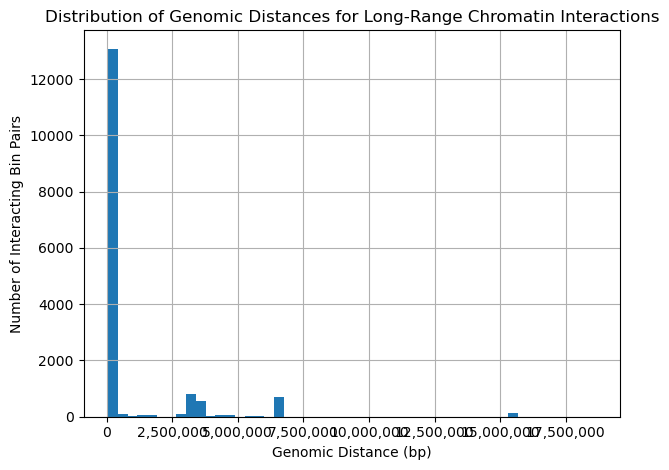

In [29]:
results_df["genomic_distance"] = abs(
    results_df["start"] - results_df["snp_bin_start"]
)

ax = results_df["genomic_distance"].hist(bins=50)
ax.set_xlabel("Genomic Distance (bp)")
ax.set_ylabel("Number of Interacting Bin Pairs")
ax.set_title("Distribution of Genomic Distances for Long-Range Chromatin Interactions")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

In [30]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12
})

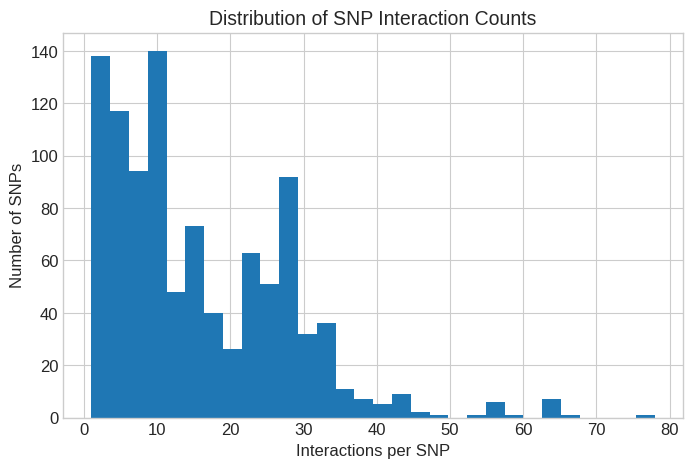

In [31]:
counts = results_df["SNP"].value_counts()

plt.hist(counts, bins=30)
plt.xlabel("Interactions per SNP")
plt.ylabel("Number of SNPs")
plt.title("Distribution of SNP Interaction Counts")
plt.show()

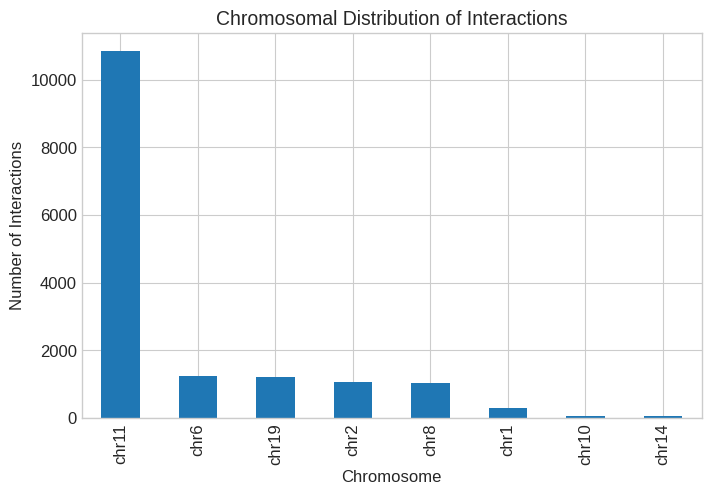

In [32]:
results_df["chr"].value_counts().plot(kind="bar")
plt.xlabel("Chromosome")
plt.ylabel("Number of Interactions")
plt.title("Chromosomal Distribution of Interactions")
plt.show()

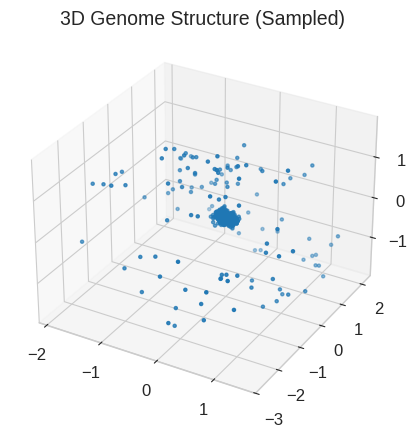

In [33]:
#3D Visualization? (Maybe it will work)
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

sample = hic3d.sample(1000)

ax.scatter(sample["x"], sample["y"], sample["z"], s=5)
ax.set_title("3D Genome Structure (Sampled)")
plt.show()

In [34]:
ax.scatter(hic3d["x"], hic3d["y"], hic3d["z"], alpha=0.1)
plt.show()


In [35]:
ax.scatter(merged["x"], merged["y"], merged["z"], s=20)
plt.show()